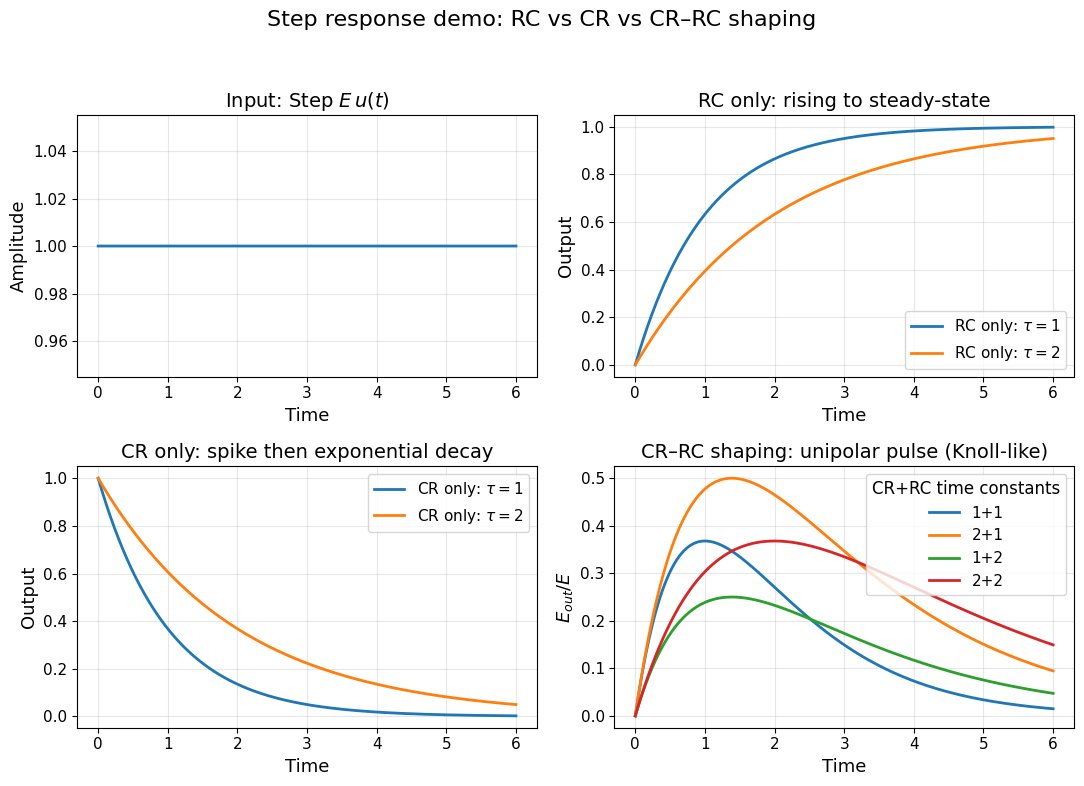

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def step(t, t0=0.0, E=1.0):
    """Unit step of amplitude E at t0."""
    return E * (t >= t0).astype(float)

def rc_lowpass_step_response(t, tau, E=1.0):
    """
    RC integrator (1st-order low-pass) response to a step input E*u(t):
    y(t) = E * (1 - exp(-t/tau)) for t>=0
    """
    y = E * (1.0 - np.exp(-t / tau))
    y[t < 0] = 0.0
    return y

def cr_highpass_step_response(t, tau, E=1.0):
    """
    CR differentiator (1st-order high-pass) response to a step input E*u(t):
    y(t) = E * exp(-t/tau) for t>=0
    (instant jump at t=0 then decays)
    """
    y = E * np.exp(-t / tau)
    y[t < 0] = 0.0
    return y

def cr_rc_step_response(t, tau1, tau2, E=1.0):
    """
    CR-RC shaping network response to a step input of amplitude E at t=0.
    This matches Knoll-like form (difference of exponentials).
    
    For tau1 != tau2:
        y(t) = E * (tau1/(tau1 - tau2)) * (exp(-t/tau1) - exp(-t/tau2))
    For tau1 == tau2 == tau:
        y(t) = E * (t/tau) * exp(-t/tau)   (limit case)
    """
    y = np.zeros_like(t, dtype=float)
    mask = t >= 0
    tt = t[mask]
    if np.isclose(tau1, tau2):
        tau = tau1
        y[mask] = E * (tt / tau) * np.exp(-tt / tau)
    else:
        y[mask] = E * (tau1 / (tau1 - tau2)) * (np.exp(-tt / tau1) - np.exp(-tt / tau2))
    return y

def main():
    # ---- Time axis (match Knoll figure style) ----
    # Use dimensionless time by setting base unit = 1 and varying tau in "units"
    t = np.linspace(0, 6.0, 2000)  # 0..6 "time units"
    E = 1.0

    # ---- Choose time constants (pairs like 1+1, 2+1, 1+2, 2+2) ----
    pairs = [(1.0, 1.0), (2.0, 1.0), (1.0, 2.0), (2.0, 2.0)]

    # ---- Plot ----
    fig = plt.figure(figsize=(11, 8))

    # Global font sizes (bigger, paper-friendly)
    plt.rcParams.update({
        "font.size": 12,
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    })

    # (A) Input step
    ax1 = fig.add_subplot(2, 2, 1)
    ax1.plot(t, step(t, 0.0, E), linewidth=2)
    ax1.set_title("Input: Step $E\\,u(t)$")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)

    # (B) RC only (integrator / low-pass) — show one tau (or a couple)
    ax2 = fig.add_subplot(2, 2, 2)
    for tau in [1.0, 2.0]:
        ax2.plot(t, rc_lowpass_step_response(t, tau, E), linewidth=2, label=f"RC only: $\\tau={tau:g}$")
    ax2.set_title("RC only: rising to steady-state")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Output")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # (C) CR only (differentiator / high-pass) — show one tau (or a couple)
    ax3 = fig.add_subplot(2, 2, 3)
    for tau in [1.0, 2.0]:
        ax3.plot(t, cr_highpass_step_response(t, tau, E), linewidth=2, label=f"CR only: $\\tau={tau:g}$")
    ax3.set_title("CR only: spike then exponential decay")
    ax3.set_xlabel("Time")
    ax3.set_ylabel("Output")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # (D) CR-RC shaping — multiple pairs like Knoll Figure 16.12
    ax4 = fig.add_subplot(2, 2, 4)
    for tau1, tau2 in pairs:
        y = cr_rc_step_response(t, tau1, tau2, E)
        ax4.plot(t, y / E, linewidth=2, label=f"{tau1:g}+{tau2:g}")
    ax4.set_title("CR–RC shaping: unipolar pulse (Knoll-like)")
    ax4.set_xlabel("Time")
    ax4.set_ylabel("$E_{out}/E$")
    ax4.legend(title="CR+RC time constants")
    ax4.grid(True, alpha=0.3)

    fig.suptitle("Step response demo: RC vs CR vs CR–RC shaping", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    main()


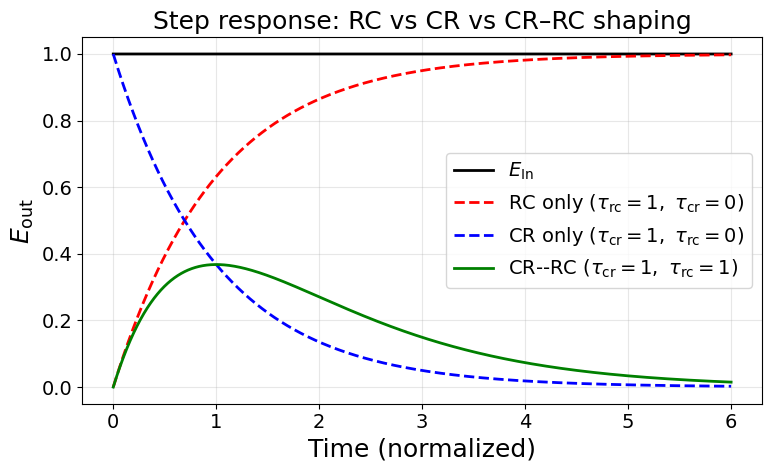

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Time axis (dimensionless)
# ----------------------------
t = np.linspace(0, 6, 2000)
E = 1.0  # step amplitude

# ----------------------------
# Input: step
# ----------------------------
step = E * (t >= 0)

# ----------------------------
# RC only (integrator / low-pass)
# tau_rc = 1, tau_cr = 0
# y = 1 - exp(-t/tau)
# ----------------------------
tau_rc = 1.0
y_rc = (1 - np.exp(-t / tau_rc)) * (t >= 0)

# ----------------------------
# CR only (differentiator / high-pass)
# tau_cr = 1, tau_rc = 0
# y = exp(-t/tau)
# ----------------------------
tau_cr = 1.0
y_cr = np.exp(-t / tau_cr) * (t >= 0)

# ----------------------------
# CR–RC shaping
# tau_cr = tau_rc = 1
# limit case: (t/tau) * exp(-t/tau)
# ----------------------------
tau = 1.0
y_crrc = (t / tau) * np.exp(-t / tau) * (t >= 0)

# ----------------------------
# Plot
# ----------------------------

plt.rcParams.update({
    'font.size': 16,          # 全局默认字号
    'axes.labelsize': 18,     # x/y 轴标签
    'axes.titlesize': 18,     # 标题
    'legend.fontsize': 14,    # 图例
    'xtick.labelsize': 14,    # x 轴刻度
    'ytick.labelsize': 14,    # y 轴刻度
    'lines.linewidth': 2.2,   # 线宽（示意图很重要）
})
plt.figure(figsize=(8, 5))

plt.plot(t, step, 'k-', linewidth=2, label=r'$E_{\mathrm{In}}$')

plt.plot(t, y_rc, 'r--', linewidth=2,
         label=r'RC only ($\tau_{\rm rc}=1,\ \tau_{\rm cr}=0$)')

plt.plot(t, y_cr, 'b--', linewidth=2,
         label=r'CR only ($\tau_{\rm cr}=1,\ \tau_{\rm rc}=0$)')

plt.plot(t, y_crrc, 'g-', linewidth=2,
         label=r'CR--RC ($\tau_{\rm cr}=1,\ \tau_{\rm rc}=1$)')

plt.xlabel('Time (normalized)')
plt.ylabel(r'$E_{\mathrm{out}}$')
plt.title('Step response: RC vs CR vs CR–RC shaping')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()
